# Group 4 | Nancy Melchert, Sophia Menchaca, Blythe Weng

## Galaxy Classification

# INFORMATION ABOUT THE DATASET

From the [zenodo.org](https://zenodo.org/records/11117528) site:

## Overview

GalaxiesML is a machine learning-ready dataset of galaxy images, photometry, redshifts, and structural parameters. It is designed for machine learning applications in astrophysics, particularly for tasks such as redshift estimation and galaxy morphology classification. The dataset comprises **286,401 galaxy images** from the Hyper-Suprime-Cam (HSC) Survey PDR2 in five filters: g, r, i, z, y, with spectroscopically confirmed redshifts as ground truth.

This dataset is particularly useful for developing machine learning models for upcoming large-scale surveys like **LSST** and **Euclid**.

## Features

- **286,401 galaxy images** in five photometric bands (g, r, i, z, y).
- Spectroscopic redshifts for each galaxy, with redshift values ranging from **0.01 to 4**.
- Morphological parameters derived from galaxy images, including **Sérsic index**, **half-light radius**, and **ellipticity**.
- **Machine learning-friendly formats**: images are provided in **HDF5** format, along with CSV metadata.


## Examples of Using GalaxiesML

Examples of uses of GalaxiesML are outlined in Do et al. (2024). The repository for example code are here:

https://github.com/astrodatalab/galaxiesml_examples


## Citation

Please cite the following papers if you use this dataset in your work:

1. **GalaxiesML Dataset**:
- Do, T. et al., *GalaxiesML: A Dataset of Galaxy Images, Photometry, Redshifts, and Structural Parameters for Machine Learning*. arXiv:2410.00271 (2024), https://arxiv.org/abs/2410.00271 

2. **Hyper Suprime-Cam Subaru Strategic Program (HSC PDR2)**:
- Aihara, H., et al., *Second Data Release of the Hyper Suprime-Cam Subaru Strategic Program*. Publications of the Astronomical Society of Japan, 71(6), 114 (2019). DOI: [10.1093/pasj/psz103](https://doi.org/10.1093/pasj/psz103)

3. **Spectroscopic Surveys**:
- Several publicly available spectroscopic redshift catalogs were used in creating this dataset. Notable sources include:
- **zCOSMOS Survey**: Lilly, S. J., et al., *The zCOSMOS 10k-Bright Spectroscopic Sample*. The Astrophysical Journal Supplement Series, 184(2), 218-229 (2009). DOI: [10.1088/0067-0049/184/2/218](https://doi.org/10.1088/0067-0049/184/2/218)
- **VIMOS Public Extragalactic Survey (VIPERS)**: Garilli, B., et al., *The VIMOS Public Extragalactic Survey (VIPERS): First Data Release of 57,204 Spectroscopic Measurements*. Astronomy & Astrophysics, 562, A23 (2014). DOI: [10.1051/0004-6361/201322790](https://doi.org/10.1051/0004-6361/201322790)
- **DEEP2 Survey**: Newman, J. A., et al., *The DEEP2 Galaxy Redshift Survey: Design, Observations, Data Reduction, and Redshifts*. The Astrophysical Journal Supplement Series, 208(1), 5 (2013). DOI: [10.1088/0067-0049/208/1/5](https://doi.org/10.1088/0067-0049/208/1/5)


## How to Access

The dataset is publicly available on **Zenodo** with the DOI: **[10.5281/zenodo.11117528](https://doi.org/10.5281/zenodo.11117528)**.

## License

This dataset is licensed under a **Creative Commons Attribution 4.0 International License (CC BY 4.0)**. You are free to share and adapt the dataset as long as appropriate credit is given. For more details, visit: **[CC BY 4.0 License](https://creativecommons.org/licenses/by/4.0/)**.

Please cite the references mentioned above if you use this dataset in your work.

THIS IS TO SEE IF I CAN FIGURE OUT THE PUSH/PULL AND GET IT INTO THE MAIN BRANCH

# Install and import necessary libraries

In [4]:
# %pip install astropy
# %pip install scipy
# %pip install seaborn
# %pip install scikit-learn

In [2]:
# install appropriate libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tkinter import Tk, filedialog

# H5PY is used for reading the .h5py files containing the galaxy images
try:
    import h5py
except ImportError: 
    %pip install h5py

# PyTorch is used for building the convolutional neural network
try:
    import torch
except ImportError:
    %pip install torch

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms


In [3]:

# Check for NVIDIA GPU, then Apple Silicon GPU, then default to CPU for training the CNN
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [4]:
# Install Hugging Face datasets
%matplotlib inline
try:
    from datasets import load_dataset
except ImportError:
    %pip install datasets

/Users/blytheweng/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/blytheweng/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# DOWNLOAD AND EXPLORE THE DATASET

Datasets are `.hdf5`. The h5py package is a Pythonic interface to the HDF5 binary data format. 
[H5PY Documentation](https://docs.h5py.org/en/stable/)

## MLGalaxies Data

In [5]:
# CoPilot helped with this code snippet to create a custom PyTorch Dataset class for loading
class GalaxyDataset(Dataset):
    def __init__(self, hdf5_path, image_key="image", labels_npy_path=None, indices_npy_path=None):
        self.hdf5_path = hdf5_path
        self.image_key = image_key
        self.labels = np.load(labels_npy_path) if labels_npy_path else None
        self.indices = np.load(indices_npy_path) if indices_npy_path else None

        # Open the file to get the length of the dataset, then close it
        with h5py.File(self.hdf5_path, "r") as f:
            self.image_count = f[self.image_key].shape[0]
    
        if self.indices is None:
            self.indices = np.arange(self.image_count)
        else:
            self.indices = self.indices.astype(np.int64)

        # Drop indices that do not exist in this HDF5 split
        valid_mask = (self.indices >= 0) & (self.indices < self.image_count)
        if not np.all(valid_mask):
            dropped = int((~valid_mask).sum())
            print(f"Dropping {dropped} out-of-range indices for {os.path.basename(self.hdf5_path)}")
            self.indices = self.indices[valid_mask]
            if self.labels is not None:
                self.labels = self.labels[valid_mask]

        if self.labels is not None and len(self.labels) != len(self.indices):
            raise ValueError(f"labels ({len(self.labels)}) and indices ({len(self.indices)}) must match")

        self.length = len(self.indices)
        self.file = None  # Will hold the open HDF5 file

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        if self.file is None:
            # Open the file inside the active process
            self.file = h5py.File(self.hdf5_path, "r")

        #Extract data (HDF5 slicing loads only this slice into RAM)    
        image = self.file[self.image_key][idx]
        img_tensor = torch.tensor(image, dtype=torch.float32)

        if self.labels is None:
            return img_tensor
        
        label = self.labels[idx]
        label_tensor = torch.tensor(label, dtype=torch.long) if label is not None else None

        return img_tensor, label_tensor


In [6]:
#Refactor of selection code to be able to reuse this code for validation and testing datasets as well
def select_hdf5_file(title="Select HDF5 file"):
    """
    Opens a file dialog to select an HDF5 file and returns the selected file path.
    Raises a ValueError if no file is selected.
    """
    Tk().withdraw()  # Hide the main window
    Tk().attributes("-topmost", True)  # Bring the file dialog to the front

    hdf5_path = filedialog.askopenfilename(
        title=title, 
        filetypes=[("HDF5 files", "*.hdf5"), ("All files", "*.*")])

    Tk().destroy()  # Close the file dialog

    if not hdf5_path:
        raise ValueError("No file selected. Please select an HDF5 file.")
    
    return hdf5_path
#hdf5_path = "data/training_sample_1000.hdf5"
def inspect_hdf5_file(hdf5_path):
    """
    Opens the selected HDF5 file and prints the keys available in the file.
    Returns the list of keys.
    """
    with h5py.File(hdf5_path, "r") as f:
        keys = list(f.keys())
    print(f"Selected file: {hdf5_path}")
    print("Keys in the HDF5 file:", keys)
    return keys

def make_dataset_and_loader(hdf5_path, image_key="image", labels_npy_path="clean_labels.npy", indices_npy_path="clean_indices.npy", batch_size=32, shuffle=True):
    """
    Creates a PyTorch Dataset and DataLoader for the given HDF5 file and associated labels/indices.
    Returns the dataset and dataloader.
    """
    dataset = GalaxyDataset(hdf5_path, image_key=image_key, labels_npy_path=labels_npy_path, indices_npy_path=indices_npy_path)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    print(f"Total Images: {len(dataset)}")
    return dataset, loader

In [7]:
# Function to visualize a sample image from the dataset along with its label (if available)
# The default of (g, r, i, z, y) is for the land-based telescope images that use 5-band photometric filters.
# Enter band names for the jwst to use this function for the jwst images as well.

def print_image(idx=0, dataset=None, band_names=("g", "r", "i", "z", "y"), cmap = "gray_r"):
    """Visualizes a sample image from the dataset along with its label (if available).
    Args:        
        idx (int): Index of the sample to visualize.
        dataset (GalaxyDataset): An instance of the GalaxyDataset class containing the images and labels.
        band_names (tuple): Optional tuple of band names corresponding to the image channels for labeling the plots.
    Raises:        
        ValueError: If the dataset is not provided or if the sample format is unexpected.
    Returns:
        None: Displays the image using matplotlib.
    """

    if dataset is None:
        raise ValueError("Pass your GalaxyDataset instance, e.g., print_image(0, dataset)")

    sample = dataset[idx]
    
    # Support both image-only and (image, label) dataset outputs
    if isinstance(sample, (tuple, list)):
        img_tensor = sample[0]
        label = sample[1] if len(sample) > 1 else None
    else:
        img_tensor = sample
        label = None

    label_text = f"class {int(label)}" if label is not None else None
    flux = img_tensor.detach().cpu().numpy()  # expected shape: (C, H, W)

    plt.figure(figsize=(12, 3))
    for i in range(flux.shape[0]):
        plt.subplot(1, flux.shape[0], i + 1)
        title = band_names[i] if i < len(band_names) else f"band {i}"
        if i == 0 and label_text is not None:
            title = f"{label_text} \n {title} "
        plt.title(title)
        plt.imshow(flux[i], cmap=cmap, origin="lower")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
# Use the refactored selection function to select the training, testing, and validation HDF5 files from
# where the user saves them on their computer. 
# This allows us to avoid hardcoding file paths and makes the code more flexible and reusable, but does not work
# on the Great Lakes environment. If using Great Lakes, you will likely need to hardcode the file paths to the HDF5 files on 
# that system, or use a different method to select the files.

# These variables will hold the file paths to the selected HDF5 files for training, testing, and validation datasets
# train_hdf5 = select_hdf5_file("Select training HDF5")
# test_hdf5 = select_hdf5_file("Select testing HDF5")
#validation_hdf5 = select_hdf5_file("Select validation HDF5")
train_hdf5 = hdf5_path
validation_hdf5 = hdf5_path

In [9]:
inspect_hdf5_file(train_hdf5)

Selected file: data/training_sample_1000.hdf5
Keys in the HDF5 file: ['image']


['image']

### Creating Labels for the images based on the morphology columns in the CSV file

In [10]:
# csv files are inside a data folder, but then in .gitignore because of the size, so we need to specify the path to read them
# These CSV files are only the morphology data, not the image data.
images_morphology_df = pd.read_csv("data/5x127x127_training_with_morphology.csv")
print("CSV DataFrame shape:", images_morphology_df.shape)


CSV DataFrame shape: (204573, 84)


Ref: https://academic.oup.com/mnras/article/529/1/499/7609698 <br>
Ref: https://www.aanda.org/articles/aa/full_html/2023/01/aa45268-22/aa45268-22.html

<u>Typical Sérsic Ranges and Morphology</u>

n ≈ 0.5 to 1: Late-Type Galaxies (LTGs) / Disks. 
>Exponential light distribution with a low degree of central concentration. These are primarily spiral and irregular galaxies with highly active star formation.

n ≈ 1 to 2.5: Pseudobulges / Transition Objects. 
>These often represent late-type spirals with significant central bulges or dwarf elliptical galaxies.

n ≈ 2.5 to 4: Early-Type Galaxies (ETGs) / Classical Bulges. 
>High central concentration with less light in the outer regions. Typical for standard elliptical galaxies and massive bulges.

n > 4: Giant Elliptical Galaxies & Brightest Cluster Galaxies (BCGs). 
>Highly concentrated, massive, and quiescent systems with extremely steep light profiles.

In [11]:
# Reusable labeling utilities for train/validation/test splits based on r_sersic_index
from pathlib import Path

# Class mapping used by the model (num_classes = 5):
# 0 = LTG / Disk (0.5 <= n < 1.0)
# 1 = Pseudobulge / Transition (1.0 <= n < 2.5)
# 2 = ETG / Classical Bulge (2.5 <= n <= 4.0)
# 3 = Giant Elliptical / BCG (n > 4.0)
# 4 = Irregular (n < 0.5)

CLASS_NAMES = {
    0: "LTG / Disk",
    1: "Pseudobulge / Transition",
    2: "ETG / Classical Bulge",
    3: "Giant Elliptical / BCG",
    4: "Irregular",
    5: "Unknown / Invalid n"
}

def build_sersic_labels(df, sersic_col="r_sersic_index", keep_unknown=False):
    """Build labels and aligned row indices from a morphology dataframe.

    If keep_unknown is False, rows with non-finite Sérsic values are dropped.
    If keep_unknown is True, those rows are kept with class 5.
    """
    if sersic_col not in df.columns:
        raise KeyError(f"Column '{sersic_col}' not found in dataframe")

    n = df[sersic_col].to_numpy()
    valid_n = np.isfinite(n)

    labels = np.full(len(df), 5, dtype=np.int64)  # default unknown/invalid
    labels[(n >= 0.5) & (n < 1.0)] = 0
    labels[(n >= 1.0) & (n < 2.5)] = 1
    labels[(n >= 2.5) & (n <= 4.0)] = 2
    labels[(n > 4.0)] = 3
    labels[(n < 0.5)] = 4

    if keep_unknown:
        keep_mask = np.ones(len(df), dtype=bool)
    else:
        keep_mask = valid_n

    clean_indices = np.where(keep_mask)[0].astype(np.int64)
    final_labels = labels[keep_mask].astype(np.int64)
    final_df = df.iloc[clean_indices].copy()

    return clean_indices, final_labels, final_df

def save_split_labels(csv_path, split_name, sersic_col="r_sersic_index", keep_unknown=False, out_dir="."):
    """Create and save <split>_indices.npy and <split>_labels.npy from one CSV."""
    df = pd.read_csv(csv_path)
    clean_indices, final_labels, final_df = build_sersic_labels(
        df, sersic_col=sersic_col, keep_unknown=keep_unknown
    )

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    idx_path = out_dir / f"{split_name}_indices.npy"
    lbl_path = out_dir / f"{split_name}_labels.npy"
    np.save(idx_path, clean_indices)
    np.save(lbl_path, final_labels)

    class_counts = {
        CLASS_NAMES[k]: int(np.sum(final_labels == k))
        for k in np.unique(final_labels)
    }

    print(f"[{split_name}] source rows: {len(df):,}")
    print(f"[{split_name}] kept rows:   {len(final_df):,}")
    print(f"[{split_name}] dropped rows: {len(df) - len(final_df):,}")
    print(f"[{split_name}] saved: {idx_path.name}, {lbl_path.name}")
    print(f"[{split_name}] class counts: {class_counts}")

    return {
        "split": split_name,
        "csv_path": csv_path,
        "indices_path": str(idx_path),
        "labels_path": str(lbl_path),
        "kept_rows": len(final_df),
        "dropped_rows": len(df) - len(final_df),
        "class_counts": class_counts,
    }

# Build labels for all splits with one consistent rule set
split_csvs = {
    "train": "data/5x127x127_training_with_morphology.csv",
    "validation": "data/5x127x127_validation_with_morphology.csv",
    "test": "data/5x127x127_testing_with_morphology.csv",
}

summaries = {}
for split_name, csv_path in split_csvs.items():
    summaries[split_name] = save_split_labels(
        csv_path=csv_path,
        split_name=split_name,
        sersic_col="r_sersic_index",
        keep_unknown=False,  # keep this False to match num_classes=5
        out_dir="."
    )

[train] source rows: 204,573
[train] kept rows:   204,573
[train] dropped rows: 0
[train] saved: train_indices.npy, train_labels.npy
[train] class counts: {'LTG / Disk': 56057, 'Pseudobulge / Transition': 121927, 'ETG / Classical Bulge': 19061, 'Giant Elliptical / BCG': 2398, 'Irregular': 5130}
[validation] source rows: 40,914
[validation] kept rows:   40,914
[validation] dropped rows: 0
[validation] saved: validation_indices.npy, validation_labels.npy
[validation] class counts: {'LTG / Disk': 11084, 'Pseudobulge / Transition': 24456, 'ETG / Classical Bulge': 3921, 'Giant Elliptical / BCG': 472, 'Irregular': 981}
[test] source rows: 40,914
[test] kept rows:   40,914
[test] dropped rows: 0
[test] saved: test_indices.npy, test_labels.npy
[test] class counts: {'LTG / Disk': 11069, 'Pseudobulge / Transition': 24465, 'ETG / Classical Bulge': 3906, 'Giant Elliptical / BCG': 466, 'Irregular': 1008}


In [63]:
# Build Sérsic-based labels
clean_indices, final_labels, labeled_images_df = build_sersic_labels(
    images_morphology_df,
    sersic_col="r_sersic_index",
    keep_unknown=False
)

# Add labels as a column
labeled_images_df["galaxy_type"] = final_labels
labeled_images_df = labeled_images_df.drop('z_sersic_index', axis=1)	

labeled_images_df["galaxy_type"] = final_labels
labeled_images_df["galaxy_type_name"] = (
    labeled_images_df["galaxy_type"]
    .map(CLASS_NAMES)
)

labeled_images_df.head()

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,galaxy_type,galaxy_type_name
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1,Pseudobulge / Transition
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1,Pseudobulge / Transition
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,1,Pseudobulge / Transition
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1,Pseudobulge / Transition
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,1,Pseudobulge / Transition


galaxy_type_name
ETG / Classical Bulge        19061
Giant Elliptical / BCG        2398
Irregular                     5130
LTG / Disk                   56057
Pseudobulge / Transition    121927
Name: count, dtype: int64


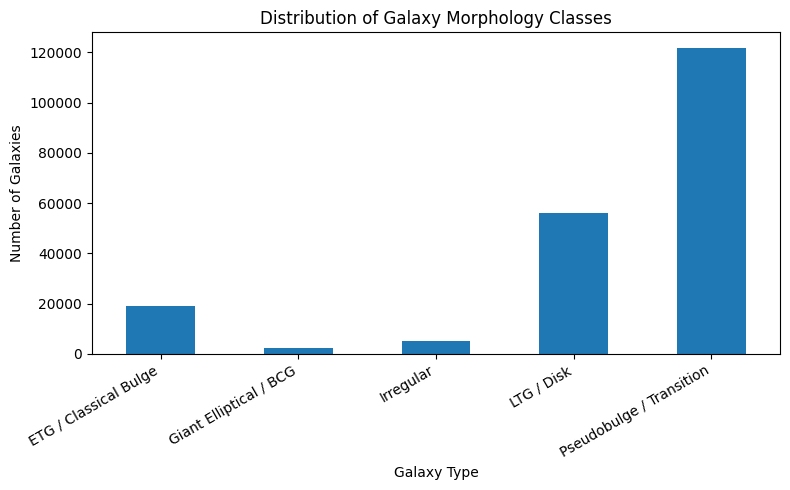

In [69]:
# Plot the distribution of galaxy types within the dataset
import matplotlib.pyplot as plt

class_counts = (
    labeled_images_df["galaxy_type_name"]
    .value_counts()
    .sort_index()
)

print(class_counts)

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Distribution of Galaxy Morphology Classes")
plt.xlabel("Galaxy Type")
plt.ylabel("Number of Galaxies")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [65]:
# Use created indices and label files to create the PyTorch Dataset and DataLoader for the training dataset
dataset, loader = make_dataset_and_loader(
    train_hdf5, 
    image_key="image", 
    labels_npy_path="train_labels.npy",
    indices_npy_path="train_indices.npy",
    batch_size=32, 
    shuffle=True)


Dropping 203573 out-of-range indices for training_sample_1000.hdf5
Total Images: 1000


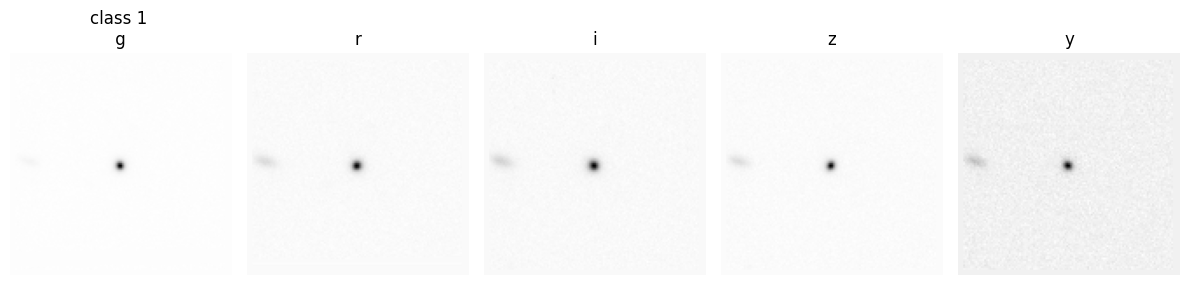

In [13]:
# Print some images from the training dataset to verify everything is working
print_image(0, dataset)

In [14]:
print_image(16_000, dataset)

IndexError: Index (16000) out of range for (0-999)

In [16]:
print_image(204_572, dataset)

IndexError: Index (204572) out of range for (0-999)

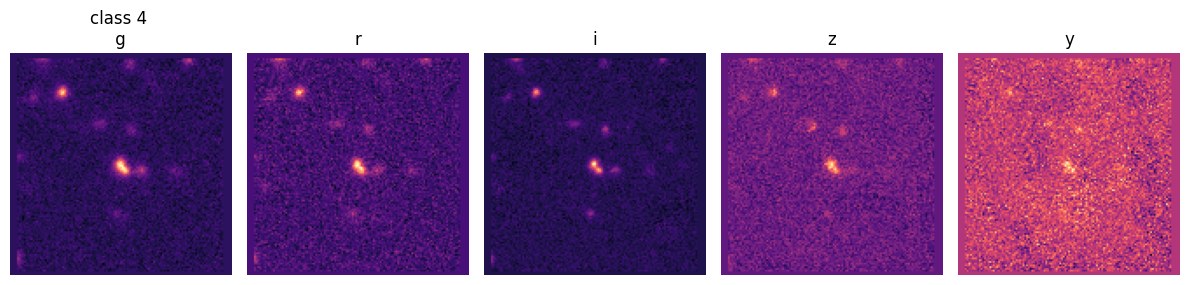

In [39]:
# Same images, but with the "magma" colormap to see if it reveals any different features than the default "gray_r" colormap
print_image(204_572, dataset, cmap="magma")

# Building and Training the CNN
## Adapting a CNN for 5 channels

Standard pre-trained CNNs expect 3 channels (RGB). GalaxyML data has 5 channels (u, g, r, i, z). We will modify a standard `ResNet18` to accept 5 channels

In [17]:
def get_galaxy_model():
    """
    Initializes a ResNet-18 model modified for our galaxy classification task.

    - The first convolutional layer is modified to accept 5 input channels (for the 5 photometric bands) 
    instead of the standard 3 (RGB).

    - The final fully connected layer is modified to output the number of classes we have defined for our 
    classification task (e.g., 5 classes for: 
        LTG / Disk, 
        Pseudobulge / Transition, 
        ETG / Classical Bulge, 
        Giant Elliptical / BCG, 
        Irregulars
    ).
    """
    
    # Start with an untrained ResNet-18 model
    model = models.resnet18(weights=None)  
    
    # Modify the first convolutional layer to accept 5 input channels instead of 3
    model.conv1 = nn.Conv2d(
        in_channels=5, 
        out_channels=64, 
        kernel_size=7, 
        stride=2, 
        padding=3, 
        bias=False
    )
    
    # Modify the final fully connected layer to output the number of classes
    num_classes = 5 
    model.fc = nn.Linear(
        in_features=model.fc.in_features, 
        out_features=num_classes
    )
    
    return model

In [20]:
# Sample to check the model architecture and output shape
model = get_galaxy_model()
sample_input = torch.randn(2, 5, 127, 127)  # Batch size of 2, 5 channels, 127x127 image
output = model(sample_input)
print("Output shape:", output.shape)  # Should be (2, num_classes)

Output shape: torch.Size([2, 5])


In [21]:
# Check the lengths of the created label and index numpy files to ensure they match and are correct
print(len(np.load("train_labels.npy")))
print(len(np.load("train_indices.npy")))

204573
204573


In [53]:
# Train the model
# remember we defined loader as the DataLoader for our training dataset, so we can use that to get batches of data for training the model.
model = get_galaxy_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
input_images, labels = next(iter(loader))
print("Input images shape:", input_images.shape)  # Should be (batch_size, 5, 127, 127)
print("Labels shape:", labels.shape)  # Should be (batch_size,)

Input images shape: torch.Size([32, 5, 127, 127])
Labels shape: torch.Size([32])


### One batch smoke test to ensure the model can process the data without errors

In [54]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps") if torch.backends.mps.is_available() else device
model = get_galaxy_model().to(device)

model.train()
input_images, labels = next(iter(loader))
input_images = input_images.to(device)
labels = labels.to(device)

optimizer.zero_grad()
logits = model(input_images)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()

preds = logits.argmax(dim=1)
acc = (preds == labels).float().mean().item()

print("One-batch loss:", float(loss.item()))
print("One-batch acc:", acc)

One-batch loss: 1.6667451858520508
One-batch acc: 0.1875


### Training Loop

In [53]:
num_epochs = 5
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = get_galaxy_model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for input_images, labels in loader:
        input_images = input_images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    print(f"Epoch {epoch+1}/{num_epochs} | loss={epoch_loss:.4f} | acc={epoch_acc:.4f}")

KeyboardInterrupt: 

#### Training CNN results 13JUN. Time: 38m 24.8s
```
Epoch 1/5 | loss=0.4777 | acc=0.8082 
Epoch 2/5 | loss=0.3367 | acc=0.8634
Epoch 3/5 | loss=0.2869 | acc=0.8833
Epoch 4/5 | loss=0.2585 | acc=0.8952
Epoch 5/5 | loss=0.2382 | acc=0.9030
```

In [40]:
# Get validation dataset and loader using the same function we used for training, 
# but with the validation HDF5 file and corresponding labels/indices numpy files

val_dataset, val_loader = make_dataset_and_loader(
    validation_hdf5,
    image_key="image",
    labels_npy_path="validation_labels.npy",
    indices_npy_path="validation_indices.npy",
    batch_size=32,
    shuffle=False
)

Total Images: 40914


In [41]:
test_dataset, test_loader = make_dataset_and_loader(
    test_hdf5,
    image_key="image",
    labels_npy_path="test_labels.npy",
    indices_npy_path="test_indices.npy",
    batch_size=32,
    shuffle=False
)

Total Images: 40914


In [46]:
# Evaluate the model
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    confusion_matrix)

def evaluate_model(model, loader, criterion, device):
    """Evaluates the model on the given DataLoader and computes various performance metrics.
    Args:        
        model: The trained PyTorch model to evaluate.
        loader: A DataLoader providing the evaluation dataset.
        criterion: The loss function used to compute the average loss.
        device: The device (CPU, GPU) on which to perform the evaluation.
    
    Returns: A dictionary containing the average loss, accuracy, F1 score, classification report, confusion matrix, and
             the true and predicted labels.
    
    """
    model.eval()
    total_loss = 0.0
    n = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_images, labels in loader:
            input_images = input_images.to(device)
            labels = labels.to(device)

            logits = model(input_images)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n += batch_size

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(n, 1)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1 Score: {macro_f1:.4f}")
    print("Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(conf_matrix)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1_score": macro_f1,
        "classification_report": report,
        "confusion_matrix": conf_matrix,
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds)
    }


In [56]:
# Keep model and input tensors on the same device for evaluation
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = model.to(device)
print(f"Evaluating on device: {device}")

Evaluating on device: mps


In [52]:
# Validate the model using the validation DataLoader and compute performance metrics
print("Evaluating on validation set...")
val_results = evaluate_model(model, val_loader, criterion, device)


Evaluating on validation set...


NameError: name 'val_loader' is not defined

In [50]:
# Evaluate the model on the test set using the test DataLoader and compute performance metrics
print("Evaluating on test set...")
test_results = evaluate_model(model, test_loader, criterion, device)

Evaluating on test set...


NameError: name 'test_loader' is not defined

## Logistic Regression

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Photometric features
# photometric filters
features = [
    'g_cmodel_mag',
    'r_cmodel_mag',
    'i_cmodel_mag',
    'z_cmodel_mag',
    'y_cmodel_mag'
]

model_df = labeled_images_df[features + ['galaxy_type']].dropna()

X = model_df[features]
y = model_df['galaxy_type']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.24      0.31     11211
           1       0.72      0.14      0.23     24386
           2       0.17      0.72      0.27      3812
           3       0.01      0.18      0.02       480
           4       0.10      0.72      0.17      1026

    accuracy                           0.23     40915
   macro avg       0.29      0.40      0.20     40915
weighted avg       0.56      0.23      0.25     40915



## Random Forest

In [67]:
# Make copy of labeled dataframe
rf_train_df = labeled_images_df.copy()

feature_cols = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag"
]

# Keep only features that actually exist in your dataframe
feature_cols = [c for c in feature_cols if c in rf_train_df.columns]

X = rf_train_df[feature_cols]
y = rf_train_df["galaxy_type"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts()


X shape: (204573, 5)
y shape: (204573,)


galaxy_type
1    97541
0    44846
2    15249
4     4104
3     1918
Name: count, dtype: int64

              precision    recall  f1-score   support

           0       0.54      0.51      0.53     11211
           1       0.79      0.39      0.52     24386
           2       0.18      0.59      0.28      3812
           3       0.03      0.08      0.04       480
           4       0.14      0.62      0.22      1026

    accuracy                           0.44     40915
   macro avg       0.34      0.44      0.32     40915
weighted avg       0.64      0.44      0.49     40915



<Figure size 600x500 with 0 Axes>

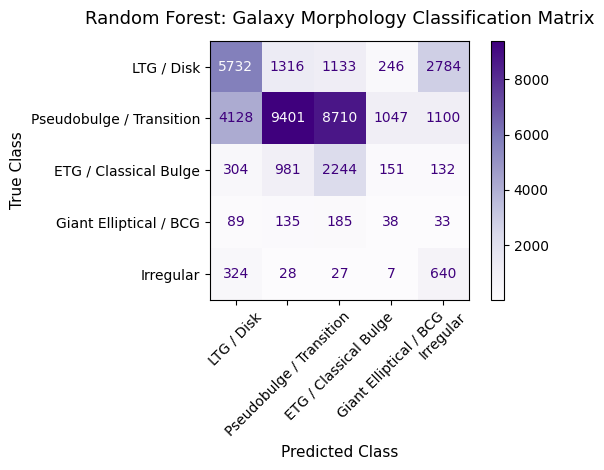

In [57]:
# Rannndom Forest Classifier 
# usefuk for feature importance and non-linear relationships, but can be prone to overfitting if not tuned properly.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
#Saving this for when we have 3 classes, but it would shown error right now because we only have 2 classes in our current dataset.
# Updated for the 5 classes

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf, 
    display_labels=['LTG / Disk', 'Pseudobulge / Transition', 'ETG / Classical Bulge', 'Giant Elliptical / BCG', 'Irregular'] 
)


disp.plot(cmap='Purples', values_format='d')
plt.title("Random Forest: Galaxy Morphology Classification Matrix", fontsize=13, pad=12)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.xticks(rotation=45)
plt.grid(False) 
plt.tight_layout()
plt.show()


In [58]:
# Get taining and test accuracies
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")

Train accuracy: 0.480 | Test accuracy: 0.441


In [59]:
# Use class_weight='balanced_subsample' in the Random Forest to automatically adjust weights for each class based on their frequency in the training data, 
# which can help mitigate the effects of class imbalance and improve model performance on minority classes.

rf_boots = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
rf_boots.fit(X_train, y_train)

y_pred_rf_boots = rf_boots.predict(X_test)

print(classification_report(y_test, y_pred_rf_boots))

              precision    recall  f1-score   support

           0       0.54      0.51      0.52     11211
           1       0.79      0.39      0.52     24386
           2       0.18      0.59      0.28      3812
           3       0.03      0.08      0.04       480
           4       0.13      0.62      0.22      1026

    accuracy                           0.44     40915
   macro avg       0.33      0.44      0.32     40915
weighted avg       0.64      0.44      0.48     40915



# JWST Dataset

In [2]:
# Image Samples
# This code is from the MultimodalUniverse Github repository, which is the source of our dataset. 
# It loads the dataset using Hugging Face's `datasets` library and retrieves an example to inspect its structure.
# Collab notebook: https://colab.research.google.com/github/MultimodalUniverse/MultimodalUniverse/blob/main/notebooks/getting_started.ipynb

dset_ls = load_dataset("MultimodalUniverse/jwst", 
                       streaming=True, 
                       split="train")
dset_ls = dset_ls.with_format("numpy")
dset_iterator = iter(dset_ls)

NameError: name 'load_dataset' is not defined

In [68]:
example = next(dset_iterator)
example.keys()

NameError: name 'dset_iterator' is not defined

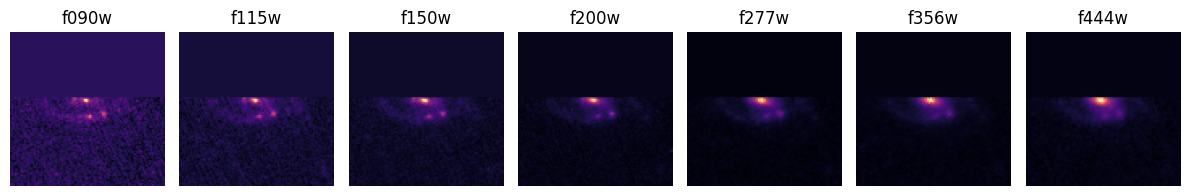

In [62]:
plt.figure(figsize=(12, 5))
n_bands = len(example["image"]["band"])
for i, b in enumerate(example["image"]["band"]):
    plt.subplot(1, n_bands, i + 1)
    plt.title(f"{b}")
    plt.imshow(example["image"]["flux"][i], cmap="magma")
    plt.axis("off")
plt.tight_layout()


Info about the photometric filters used in the JWST dataset: https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-instrumentation/miri-filters-and-dispersers#gsc.tab=0

In [43]:
# Use the file grabber to get the JWST HDF5 files for training, validation, and testing datasets, 
# then inspect the keys in the HDF5 files to understand the structure of the data and how to access 
# the images and labels for training the model.

jwst_hdf5 = select_hdf5_file("Select JWST HDF5 file")
jwst_keys = inspect_hdf5_file(jwst_hdf5)

Selected file: /Volumes/NMELCHERT/MultimodelUniverse/jwst/primer-cosmos/healpix=1703/001-of-001.hdf5
Keys in the HDF5 file: ['a_image', 'apcorr_0', 'apcorr_1', 'apcorr_2', 'area_auto', 'area_iso', 'b_image', 'bkg_aper_0', 'bkg_aper_1', 'bkg_aper_2', 'bkg_auto', 'cflux', 'cpeak', 'cxx_image', 'cxy_image', 'cyy_image', 'dec', 'dummy_err', 'dummy_flux', 'errx2', 'errxy', 'erry2', 'f090w_bkg_aper_0', 'f090w_bkg_aper_1', 'f090w_bkg_aper_2', 'f090w_corr_0', 'f090w_corr_1', 'f090w_corr_2', 'f090w_ecorr_0', 'f090w_ecorr_1', 'f090w_ecorr_2', 'f090w_etot_0', 'f090w_etot_1', 'f090w_etot_2', 'f090w_flag_aper_0', 'f090w_flag_aper_1', 'f090w_flag_aper_2', 'f090w_flux_aper_0', 'f090w_flux_aper_1', 'f090w_flux_aper_2', 'f090w_fluxerr_aper_0', 'f090w_fluxerr_aper_1', 'f090w_fluxerr_aper_2', 'f090w_mask_aper_0', 'f090w_mask_aper_1', 'f090w_mask_aper_2', 'f090w_tot_0', 'f090w_tot_1', 'f090w_tot_2', 'f090w_tot_corr', 'f105w_bkg_aper_0', 'f105w_bkg_aper_1', 'f105w_bkg_aper_2', 'f105w_corr_0', 'f105w_corr_1

In [44]:
keys_with_image = [key for key in jwst_keys if "image" in key.lower()]
for k in keys_with_image:
    print(f"Key: {k}, shape: {h5py.File(jwst_hdf5, 'r')[k].shape}")
#print("Keys containing 'image':", keys_with_image)

Key: a_image, shape: (51058,)
Key: b_image, shape: (51058,)
Key: cxx_image, shape: (51058,)
Key: cxy_image, shape: (51058,)
Key: cyy_image, shape: (51058,)
Key: image_band, shape: (51058, 7)
Key: image_flux, shape: (51058, 7, 96, 96)
Key: image_ivar, shape: (51058, 7, 96, 96)
Key: image_mask, shape: (51058, 7, 96, 96)
Key: image_psf_fwhm, shape: (51058, 7)
Key: image_scale, shape: (51058, 7)
Key: theta_image, shape: (51058,)
Key: x2_image, shape: (51058,)
Key: x_image, shape: (51058,)
Key: xy_image, shape: (51058,)
Key: y2_image, shape: (51058,)
Key: y_image, shape: (51058,)


The keys with shapes that are (51058, 7, 96, 96) are likely the image data for the JWST dataset, where 51058 is the number of samples, 7 is the number of photometric bands, and 96x96 is the image size. Use the `image_flux` key to access the image data when creating your PyTorch Dataset for the JWST images. `image_ivar` and `image_mask` are for quality and image filtering.

In [45]:
jwst_dataset = GalaxyDataset(jwst_hdf5, image_key="image_flux")

# Find the 7 band names in the HDF5 file and print them out
with h5py.File(jwst_hdf5, "r") as f:
    band_names = f["image_band"][:1].astype(str)  # Convert bytes to strings
print("Band names in the JWST HDF5 file:", band_names)

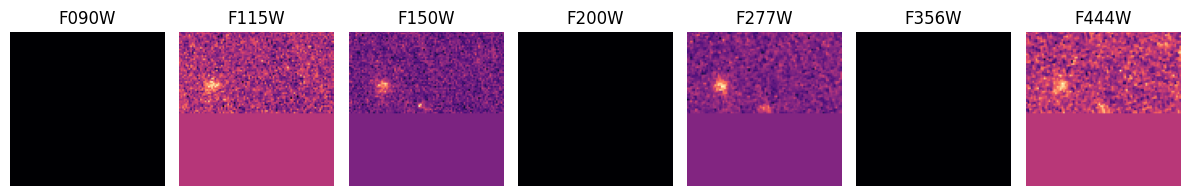

In [47]:
# Attempt to visualize a sample image from the JWST dataset to verify we can access the data correctly
print_image(0, jwst_dataset, band_names=("F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"), cmap="magma")


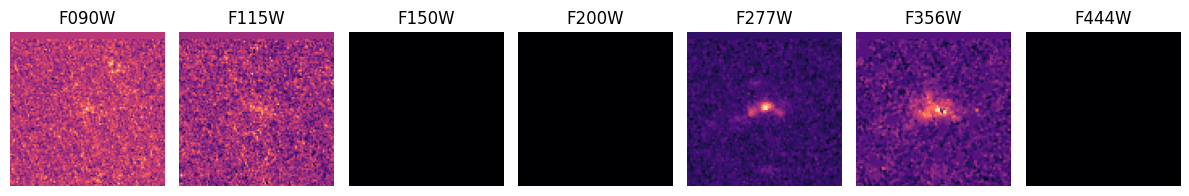

In [48]:
print_image(51_057, jwst_dataset, band_names=("F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"), cmap="magma")

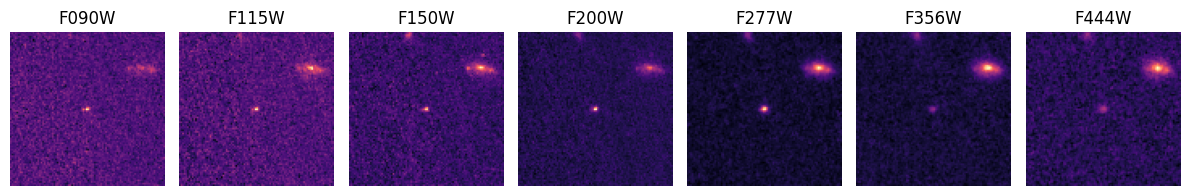

In [49]:
print_image(10_000, jwst_dataset, band_names=("F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"), cmap="magma")

There are no labels in the `jwst_dataset` to train a supervised model, but we can still visualize the images.
JWST data may be a good candidate for unsupervised learning.

### Consider Feature Engineering and Selection for the final report. 
From report requirements:
>Feature engineering (6 points)

> Describe the steps you used to get from the raw input data to the final features used w/ supervised and unsupervised ML methods.

> Explain any initial preprocessing that was required to handle noisy or missing data.

> Be sure to include a complete list of all final features (in an appendix if necessary).


## Unsupervised ML Model

My idea rn is to cluster galaxies on their multi-band morphology/photometry profile and then use those clusters as a feature for classification, or to see if they correspond to known morphological classes.

In [72]:
rf_train_df.columns.tolist()

['coord',
 'dec',
 'g_central_image_pop_10px_rad',
 'g_central_image_pop_15px_rad',
 'g_central_image_pop_5px_rad',
 'g_cmodel_mag',
 'g_cmodel_magsigma',
 'g_ellipticity',
 'g_half_light_radius',
 'g_isophotal_area',
 'g_major_axis',
 'g_minor_axis',
 'g_peak_surface_brightness',
 'g_petro_rad',
 'g_pos_angle',
 'g_sersic_index',
 'i_central_image_pop_10px_rad',
 'i_central_image_pop_15px_rad',
 'i_central_image_pop_5px_rad',
 'i_cmodel_mag',
 'i_cmodel_magsigma',
 'i_ellipticity',
 'i_half_light_radius',
 'i_isophotal_area',
 'i_major_axis',
 'i_minor_axis',
 'i_peak_surface_brightness',
 'i_petro_rad',
 'i_pos_angle',
 'i_sersic_index',
 'object_id',
 'r_central_image_pop_10px_rad',
 'r_central_image_pop_15px_rad',
 'r_central_image_pop_5px_rad',
 'r_cmodel_mag',
 'r_cmodel_magsigma',
 'r_ellipticity',
 'r_half_light_radius',
 'r_isophotal_area',
 'r_major_axis',
 'r_minor_axis',
 'r_peak_surface_brightness',
 'r_petro_rad',
 'r_pos_angle',
 'r_sersic_index',
 'ra',
 'skymap_id',
 '

In [73]:
# can move these to the top later
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
unsup_train_df = rf_train_df.copy()

#Not sure which features would be best for clustering, but I will start with the photometric magnitudes and some of the i-band morphology features
#  since those seem to be the most relevant to galaxy structure and redshift based on our earlier correlation analysis.
cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "r_ellipticity", "i_half_light_radius", "i_isophotal_area", "i_peak_surface_brightness", "i_petro_rad", 
    "i_ellipticity", "g_ellipticity"
]

cluster_features = [c for c in cluster_features if c in unsup_train_df.columns]
 
cluster_df = unsup_train_df[cluster_features].dropna()
 
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)
 
# Pick k based on silhouette score 
# measures how similar an object is to its own cluster compared to other clusters, with higher scores indicating better-defined clusters.
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores by k:", sil_scores)
print("Best k:", best_k)
 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df["morph_cluster"] = kmeans.fit_predict(X_cluster).astype(str)

First one used a sersic index, but that wouldn't make any sense since we would have to put it in as a feature

cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "g_sersic_index", "r_sersic_index", "i_sersic_index", "z_sersic_index", "y_sersic_index",
    "r_ellipticity", "i_half_light_radius"
]

Silhouette scores by k: {2: 0.2625173142663438, 3: 0.2638724791297067, 4: 0.26287306379101716, 5: 0.2555358072012217, 6: 0.19748655961165257, 7: 0.1874636529282637}
Best k: 3


cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "r_ellipticity", "i_half_light_radius", "i_isophotal_area", "i_peak_surface_brightness", "i_petro_rad", 
    "i_ellipticity", "g_ellipticity"
]


Silhouette scores by k: {2: 0.2775704309367226, 3: 0.24920954920816976, 4: 0.24919139935657394, 5: 0.24031576973057436, 6: 0.20147958336445376, 7: 0.20055317360909672}
Best k: 2

###  Now that we have a model, I want to make the cluster a new feature to be used in the random forest model. May or may not be useful in predicting the galaxy class. 

In [142]:
model_df_with_cluster = unsup_train_df.merge(
    cluster_df[["morph_cluster"]],
    left_index=True, right_index=True, how="left"
)

In [143]:
model_df_with_cluster.head()

,image_idx,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,...,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index,gz2class,separation,galaxy_type,morph_cluster
29783,29783,"b'(-204784.265625, 24080.68359375, -5356.69287...",-1.488138,1,1,1,17.735281,0.000706,0.472,14.519,...,15.135,7.995,-8.2591,5.28,-41.58,1.007,Sc?t,0.096143,2,1
29788,29788,"b'(-204671.875, 24544.234375, -7223.24072265625)'",-2.006866,1,1,1,17.208687,0.000557,0.471,12.845,...,12.136,6.760,-8.8767,5.94,-14.62,1.637,Sb2t,0.044243,1,2
29791,29791,"b'(-204676.09375, 24608.78515625, -6875.787109...",-1.910295,1,1,1,18.474453,0.001769,0.300,21.335,...,12.582,9.017,-7.4077,8.58,46.19,2.157,Sc?m,0.059871,1,1
29799,29799,"b'(-204731, 24402.173828125, -5909.5068359375)'",-1.641754,1,1,1,17.853600,0.000837,0.669,18.452,...,20.103,6.638,-7.4197,7.26,87.59,1.563,Sen,0.103360,1,1
29810,29810,"b'(-205254.5625, 18951.892578125, -7520.560546...",-2.089508,1,1,1,17.087647,0.000892,0.713,15.722,...,19.923,6.080,-8.9362,5.28,38.69,1.563,Ser,0.044021,2,2


In [ ]:
# since the cluster numbers are arbitrary, using the values of the cluster labels themselves is not meaningful for classification, 
# but they can still be used as categorical features to help the model learn patterns in the data.

# stuck here for now, but the idea is to use the cluster labels as additional features in the classification model, 
# which could potentially improve performance by providing a way for the model to learn from the underlying structure in the data